# PHÂN TÍCH CHẤT LƯỢNG CÂU HỎI CỦA CÁC ĐỀ THI CHUẨN HOÁ VÀ ĐÁNH GIÁ NĂNG LỰC THÍ SINH

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import irt
import ctt
import item_plot as ip

In [2]:
df_dot1 = pd.read_csv("lan1.csv")
df_dot2 = pd.read_csv("lan2.csv")
da_1 = pd.read_csv("ans_1.csv", delimiter=";")
da_2 = pd.read_csv("ans_2.csv", delimiter=";")

df_dot1.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot2.drop_duplicates(subset=['Email'], keep='last', inplace=True)

In [3]:
df_dot1, df_dot2, da_1, da_2

(        SBD                     Timestamp  \
 0    110001   2025/10/19 4:46:46 PM GMT+7   
 1    110002   2025/10/18 1:05:06 PM GMT+7   
 2    110003  2025/10/19 12:42:42 PM GMT+7   
 3    110004   2025/10/19 5:48:44 PM GMT+7   
 4    110005   2025/10/18 1:25:28 PM GMT+7   
 ..      ...                           ...   
 471  110472   2025/10/11 3:07:53 PM GMT+7   
 472  110473  2025/10/19 12:00:37 AM GMT+7   
 473  110474   2025/10/03 9:24:46 PM GMT+7   
 474  110475  2025/10/18 10:14:54 PM GMT+7   
 475  110476                           NaN   
 
                                    Email                   Name Gioi  MaDe  \
 0             07vudinhchien8a2@gmail.com          Vũ Đình Chiến  Nam   107   
 1                    09022008a@gmail.com                 beaver   Nữ   107   
 2    19.nguyenminhtuankiet.9.1@gmail.com  Nguyễn Minh Tuấn Kiệt  Nam   107   
 3      2008.lvklinh.nguyenhien@gmail.com              kling_296   Nữ   107   
 4                2008trankhanh@gmail.com        Tr

In [4]:
# Tổng số thí sinh thi mỗi đề
print(f'Tổng số thí sinh thi đề 1: {df_dot1.shape[0]}')
print(f'Tổng số thí sinh thi đề 2: {df_dot2.shape[0]}')

Tổng số thí sinh thi đề 1: 469
Tổng số thí sinh thi đề 2: 752


In [5]:
thisinh_1 = pd.Series(df_dot1['Email'])
thisinh_2 = pd.Series(df_dot2['Email'])

# cho biết có bao nhiêu thí sinh nào thi cả 2 đề hay chỉ thi 1 trong 2 đề
thisinh_both = pd.Series(list(set(thisinh_1) & set(thisinh_2)))
thisinh_only1 = pd.Series(list(set(thisinh_1) - set(thisinh_2)))
thisinh_only2 = pd.Series(list(set(thisinh_2) - set(thisinh_1)))
print('--- Thống kê thí sinh có tham gia thi 2 đề ---')
print(f'Số thí sinh thi cả 2 đề: {thisinh_both.shape[0]}')
print(f'Số thí sinh chỉ thi đề 1: {thisinh_only1.shape[0]}')
print(f'Số thí sinh chỉ thi đề 2: {thisinh_only2.shape[0]}')

--- Thống kê thí sinh có tham gia thi 2 đề ---
Số thí sinh thi cả 2 đề: 241
Số thí sinh chỉ thi đề 1: 228
Số thí sinh chỉ thi đề 2: 511


In [6]:
gioi= pd.DataFrame(
    {'Đề 1': df_dot1['Gioi'],
    'Đề 2': df_dot2['Gioi']}
)

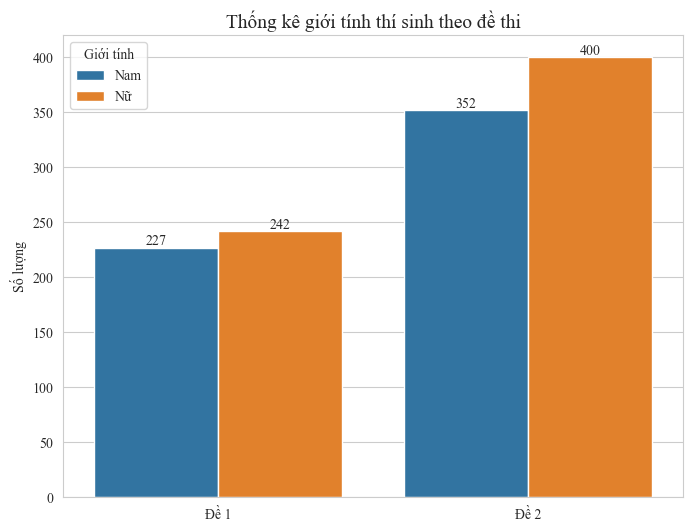

In [7]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(8, 6))
sns.countplot(data=gioi.melt(var_name='Đề', value_name='Giới tính'), x='Đề', hue='Giới tính')
plt.title('Thống kê giới tính thí sinh theo đề thi', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')
#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [8]:
# lập thành bảng thống kê
gioi_counts = gioi.apply(pd.Series.value_counts).astype(int)
gioi_counts

,Đề 1,Đề 2
Nữ,242,400
Nam,227,352


In [9]:
df_chamdiem_1 = ip.ketQuaCham(df_dot1, da_1)
df_chamdiem_2 = ip.ketQuaCham(df_dot2, da_2)

In [10]:
order_kho = ['Rất dễ', 'Dễ', 'Tương đối dễ', 'Bình thường', 'Tương đối khó', 'Khó','Rất khó']
order_pb  = ['Kém', 'Chưa tốt', 'Chấp nhận được', 'Tương đối tốt', 'Tốt', 'Rất tốt','Quá tốt']
order_nhieu = ["Kém", "Yếu", "Bình thường", "Tốt"]

In [11]:
df_TV1, df_TA1, df_TO1, df_KH1 = ip.tach_phan(df_chamdiem_1)
df_TV2, df_TA2, df_TO2, df_KH2 = ip.tach_phan(df_chamdiem_2)

for data in [df_TV1, df_TA1, df_TO1, df_KH1, df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)

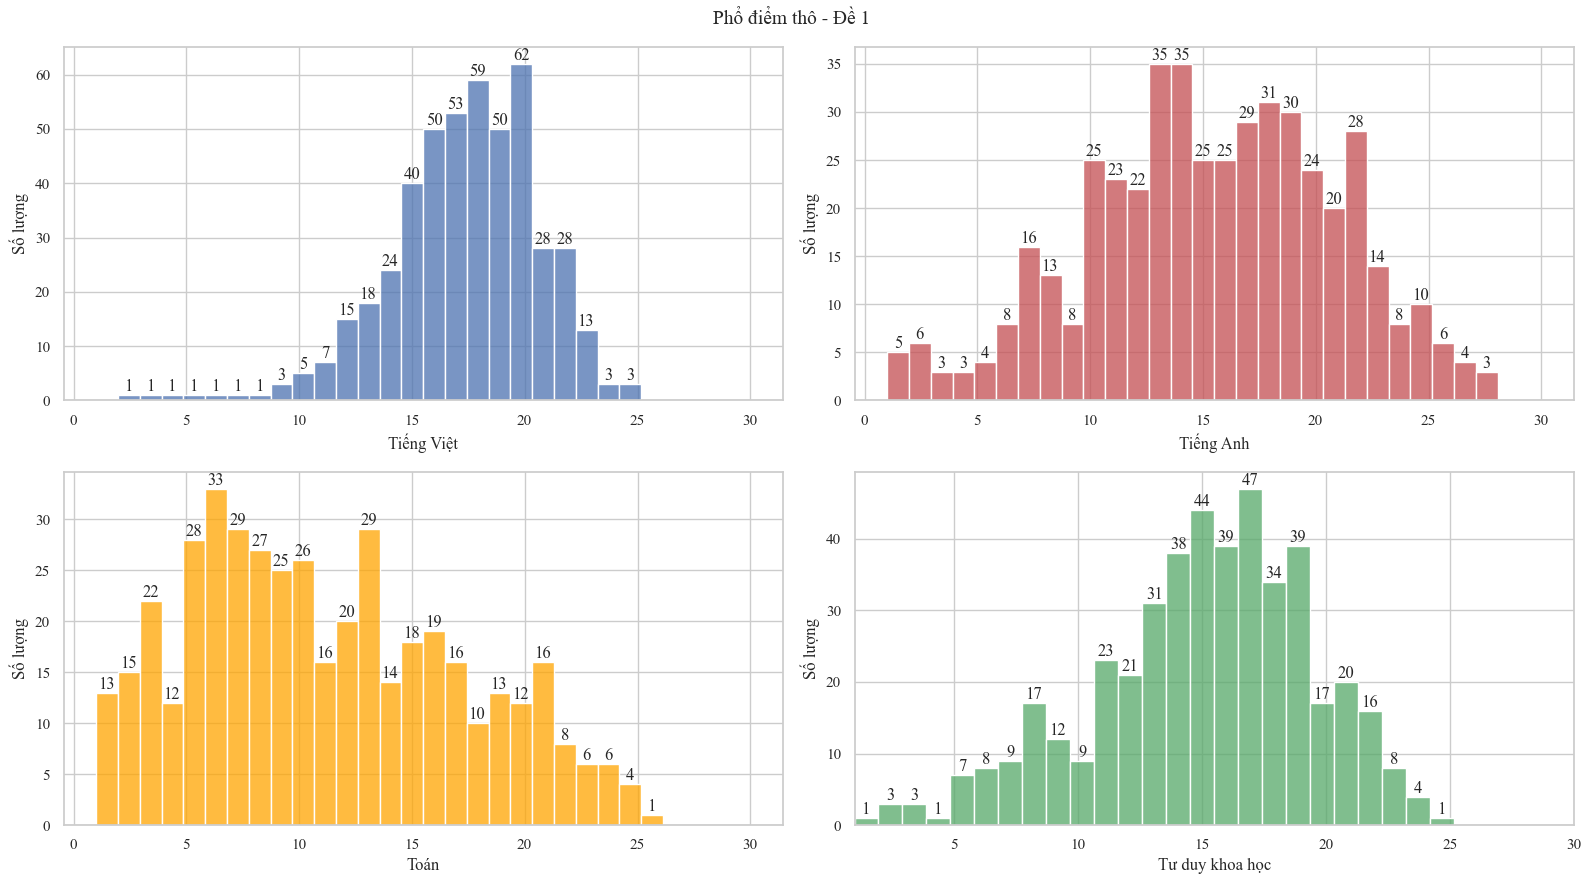

In [12]:
df_raw1 = df_TV1[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw1 = df_raw1.merge(df_TA1[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_TO1[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_KH1[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')

ip.draw_plot(df_raw1, col_name='Raw', title='Phổ điểm thô - Đề 1', range=(1,30))

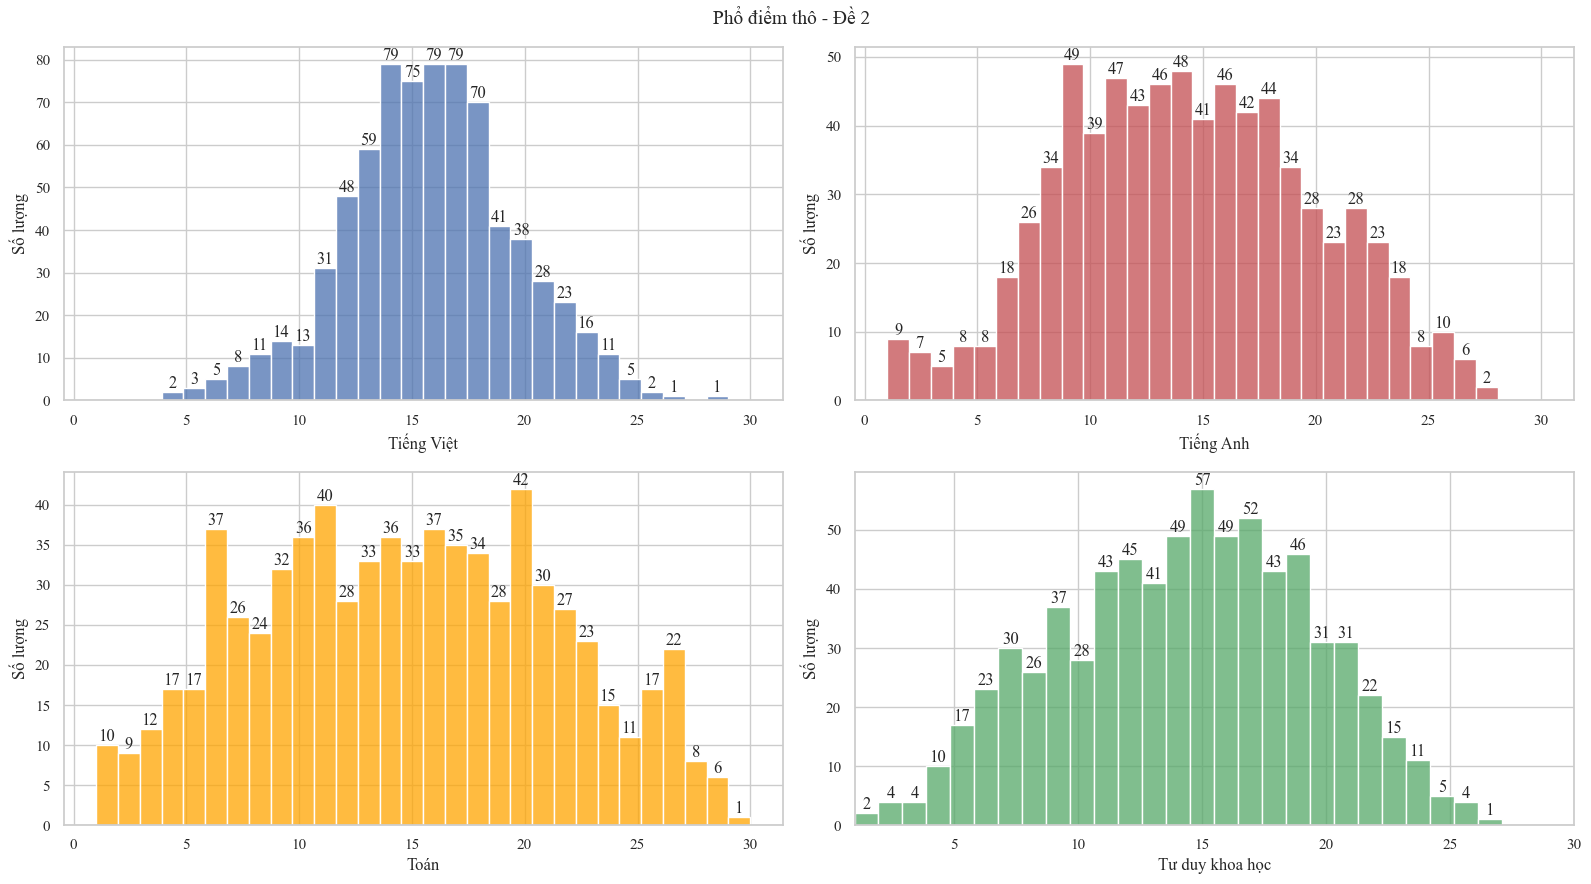

In [13]:
df_raw2 = df_TV2[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw2 = df_raw2.merge(df_TA2[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_TO2[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_KH2[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw2, col_name='Raw', title='Phổ điểm thô - Đề 2', range=(1,30))

In [14]:
rawtotal_1 = pd.Series(df_TV1['Raw'] + df_TA1['Raw'] + df_TO1['Raw'] + df_KH1['Raw'])
rawtotal_2 = pd.Series(df_TV2['Raw'] + df_TA2['Raw'] + df_TO2['Raw'] + df_KH2['Raw'])


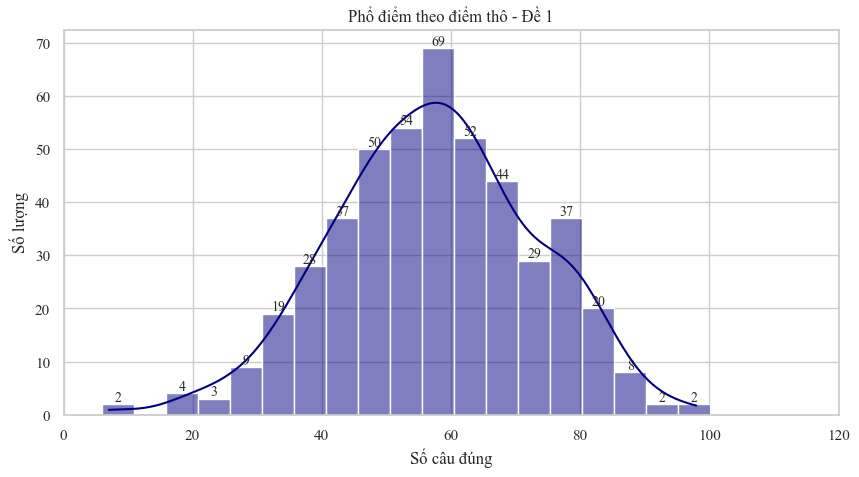

In [15]:
ip.plot_total(rawtotal_1, title='Phổ điểm theo điểm thô - Đề 1', range=(1,120), color='navy', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

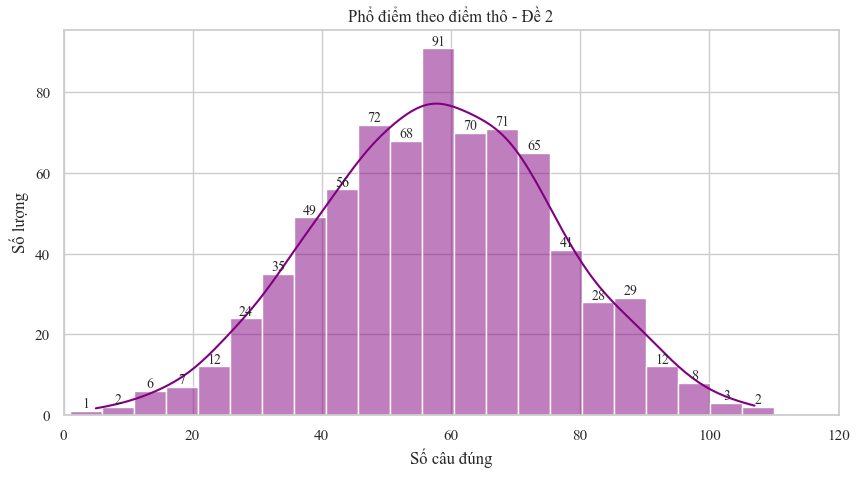

In [16]:
ip.plot_total(rawtotal_2, title='Phổ điểm theo điểm thô - Đề 2', range=(1,120), color='purple', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

In [17]:
diff_1, diff_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_1 = pd.concat([diff_1, b], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_2 = pd.concat([diff_2, b], axis=0)

diff_1 = diff_1.rename({0: 'CTT'}, axis=1)
diff_2 = diff_2.rename({0: 'CTT'}, axis=1)

In [18]:
diff_2.describe()

,CTT
count,120.000000
mean,0.492247
std,0.182863
min,0.084906
25%,0.374675
50%,0.461228
75%,0.613752
max,0.913747


In [19]:
def b_category(diff):
    if diff > 0.9:
        return 'Rất dễ'
    elif diff > 0.75:
        return 'Dễ'
    elif diff > 0.6:
        return 'Tương đối dễ'
    elif diff > 0.4:
        return 'Bình thường'
    elif diff > 0.25:
        return 'Tương đối khó'
    elif diff > 0.1:
        return 'Khó'
    else:
        return 'Rất khó'
    
diff_1['Phân loại'] = diff_1['CTT'].apply(b_category)
diff_2['Phân loại'] = diff_2['CTT'].apply(b_category)

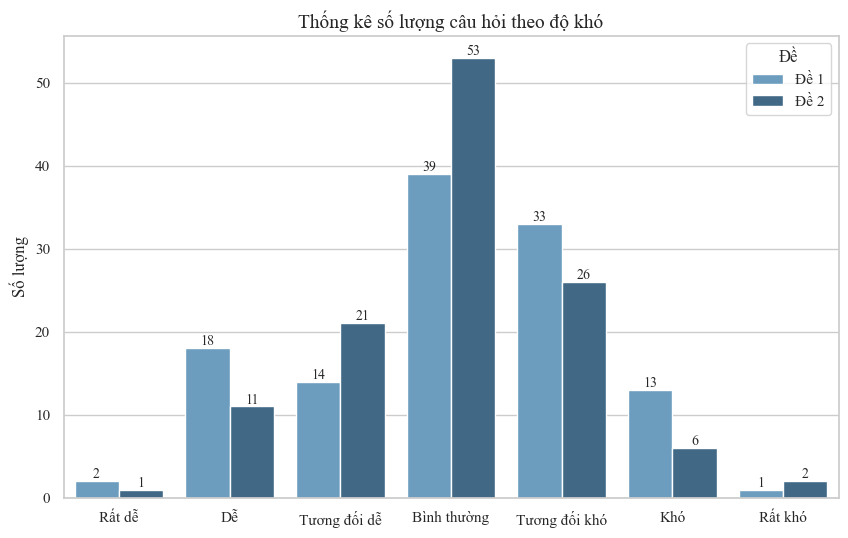

In [20]:
ip.plot_item(diff_1, diff_2, title='Thống kê số lượng câu hỏi theo độ khó', order=order_kho, palette='Blues_d', size=(10,6))

In [59]:
diff_1

,CTT,Phân loại,Phần thi
Cau1,0.784188,Dễ,Tiếng Việt
Cau2,0.882479,Dễ,Tiếng Việt
Cau3,0.831197,Dễ,Tiếng Việt
Cau4,0.121795,Khó,Tiếng Việt
Cau5,0.314103,Tương đối khó,Tiếng Việt
...,...,...,...
Cau116,0.263274,Tương đối khó,Tư duy khoa học
Cau117,0.508850,Bình thường,Tư duy khoa học
Cau118,0.165929,Khó,Tư duy khoa học
Cau119,0.579646,Bình thường,Tư duy khoa học


In [21]:
diff_1['Phần thi'] = (
    diff_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_2['Phần thi'] = (
    diff_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ khó xét theo từng phần thi của mỗi đợt')

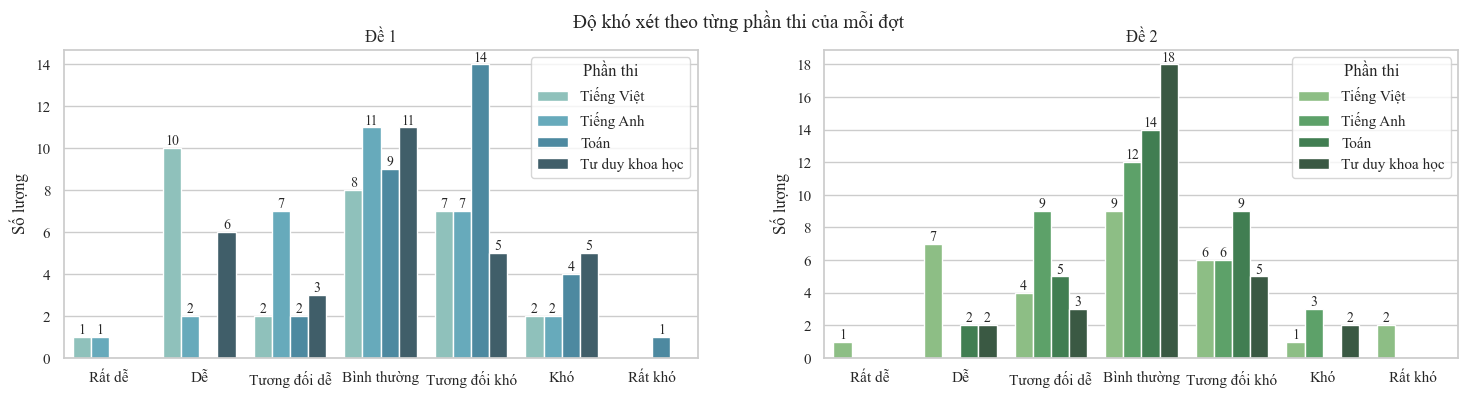

In [79]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 4))
sns.countplot(data=diff_1, x='Phân loại', palette='GnBu_d', ax=axes[0], hue='Phần thi', order=order_kho)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=diff_2, x='Phân loại', palette='YlGn_d', ax=axes[1], hue='Phần thi', order=order_kho)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ khó xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_6712\1872895512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_6712\1872895512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])


Text(0.5, 0, '')

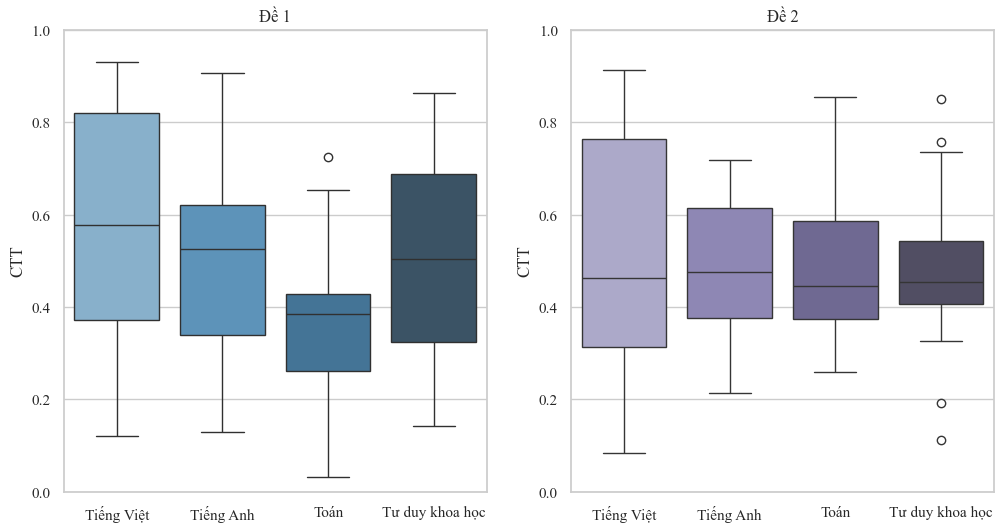

In [22]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_ylim(0,1)
axes[0].set_xlabel(None)
sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_ylim(0,1)
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ khó theo từng phần thi của mỗi đợt', fontsize=16)

In [23]:
disc_1, disc_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_1 = pd.concat([disc_1, a], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_2 = pd.concat([disc_2, a], axis=0)

disc_1 = disc_1.rename({0: 'D-Index'}, axis=1)
disc_2 = disc_2.rename({0: 'D-Index'}, axis=1)

In [24]:
def a_category(disc):
    if disc <= 0:
        return 'Kém'
    elif disc <= 0.20:
        return 'Chưa tốt'
    elif disc <= 0.40:
        return 'Chấp nhận được'
    elif disc <= 0.60:
        return 'Tương đối tốt'
    elif disc <= 0.80:
        return 'Tốt'
    elif disc <= 1.0:
        return 'Rất tốt'
    else:
        return 'Quá tốt'
    
disc_1['Phân loại'] = disc_1['D-Index'].apply(a_category)
disc_2['Phân loại'] = disc_2['D-Index'].apply(a_category)

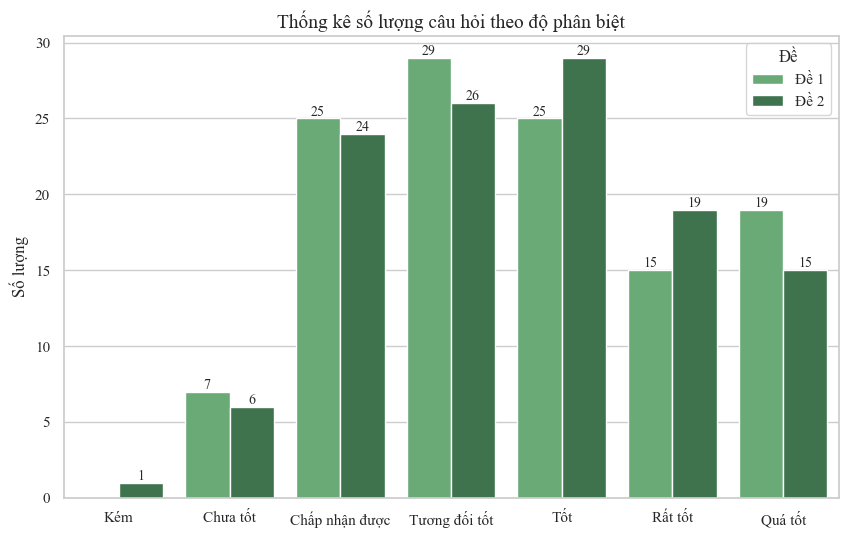

In [25]:
ip.plot_item(disc_1, disc_2, title='Thống kê số lượng câu hỏi theo độ phân biệt', order=order_pb, palette='Greens_d', size=(10,6))

In [26]:
disc_1['Phần thi'] = (
    disc_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_2['Phần thi'] = (
    disc_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ phân biệt xét theo từng phần thi của mỗi đợt')

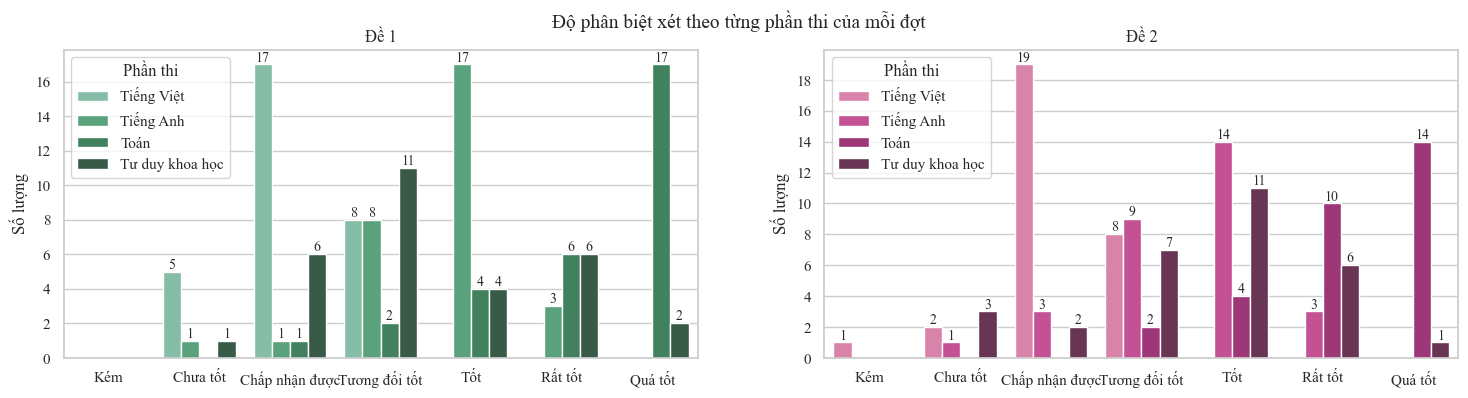

In [80]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 4))
sns.countplot(data=disc_1, x='Phân loại', palette='BuGn_d', ax=axes[0], hue='Phần thi', order=order_pb)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=disc_2, x='Phân loại', palette='RdPu_d', ax=axes[1], hue='Phần thi', order=order_pb)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ phân biệt xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_6712\799261752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_6712\799261752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])


Text(0.5, 0, '')

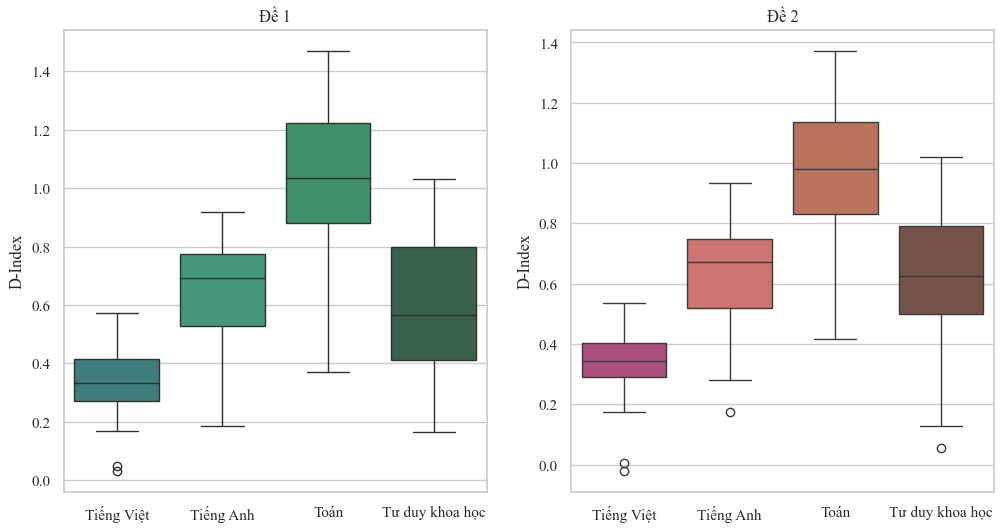

In [27]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_xlabel(None)
sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ phân biệt theo từng phần thi của mỗi đợt', fontsize=16)

In [28]:
def do_nhieu(data: pd.DataFrame, chamdiem, answer: pd.DataFrame, start, end):
    # Merge 1 lần
    data = data.merge(chamdiem[['SBD', 'Raw', 'Null']], on='SBD', how='left')
    ans_row = answer.iloc[0]

    # DataFrame lưu kết quả tổng hợp
    df_all = pd.DataFrame(columns=["A", "B", "C", "D", "Ans"])

    # Lọc thí sinh hợp lệ
    valid = data[data['Null'] < 30]

    for stt in range(start, end + 1):
        std = valid['Raw'].std()
        cau_col = f"Cau{stt}"
        correct = ans_row[cau_col]

        pbcc_dict = {}

        for opt in ["A", "B", "C", "D"]:

            true_group  = valid.loc[valid[cau_col] == opt, 'Raw']
            false_group = valid.loc[valid[cau_col] != opt, 'Raw']
            if true_group.shape[0] == 0 or false_group.shape[0] == 0:
                pb = np.nan
            else:
                p = true_group.shape[0] / valid[cau_col].shape[0]
                pb = ctt.cal_pbcc(true_group, false_group, std, p)

            pbcc_dict[opt] = pb

        # PBCC của đáp án đúng
        pbcc_ans = pbcc_dict.get(correct, np.nan)

        # Append 1 dòng vào df_all
        df_all.loc[f'Cau{stt}'] = [
            pbcc_dict["A"],
            pbcc_dict["B"],
            pbcc_dict["C"],
            pbcc_dict["D"],
            pbcc_ans
        ]

    return df_all


In [29]:
nhieu_1 = pd.concat([do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TV1, start=1, end=30),
                     do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TA1, start=31, end=60),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TO1, start=61, end=90),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_KH1, start=91, end=120),], axis=0)

In [30]:
nhieu_1

,A,B,C,D,Ans
Cau1,-0.090698,-0.077724,0.145350,-0.050370,0.145350
Cau2,-0.077654,-0.164355,0.200580,-0.258847,0.200580
Cau3,0.023497,0.010622,0.020272,-0.064765,0.010622
Cau4,0.098663,0.055808,-0.015382,-0.074254,0.055808
Cau5,-0.137573,0.120029,-0.081774,0.114395,0.120029
...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,0.231577
Cau117,-0.146751,-0.147345,-0.014308,0.505123,0.505123
Cau118,-0.185613,-0.029800,0.259071,0.210703,0.210703
Cau119,-0.087406,0.508710,-0.103076,-0.149028,0.508710


In [31]:
nhieu_2 = pd.concat([
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TV2, start=1, end=30),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TA2, start=31, end=60),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TO2, start=61, end=90),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_KH2, start=91, end=120),
], axis=0)


In [32]:
nhieu_2

,A,B,C,D,Ans
Cau1,-0.112050,-0.119164,-0.238992,0.372054,0.372054
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.315619
Cau3,-0.072206,-0.204496,0.255094,-0.106073,0.255094
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.265416
Cau5,-0.039716,-0.208780,-0.179729,0.298750,0.298750
...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,0.402168
Cau117,-0.198114,-0.057453,-0.174101,0.376236,0.376236
Cau118,-0.124422,-0.235191,-0.159096,0.557978,0.557978
Cau119,0.519316,-0.120816,-0.161446,-0.078337,0.519316


In [33]:
# hàm phân loại độ nhiễu câu hỏi
def label_distract(data):
    scale = 0
    for col in data.drop(columns='Ans').index:  # bỏ qua cột đáp án đúng
        if data[col] == data['Ans']:
            continue
        else:
            scale += (data[col]<0)
    if scale == 3:
        return "Tốt"
    elif scale == 2:
        return "Bình thường"
    elif scale == 1:
        return "Yếu"
    else:  
        return "Kém"

In [34]:
nhieu_1['Phân loại'] = nhieu_1.apply(label_distract, axis=1)
nhieu_1

,A,B,C,D,Ans,Phân loại
Cau1,-0.090698,-0.077724,0.145350,-0.050370,0.145350,Tốt
Cau2,-0.077654,-0.164355,0.200580,-0.258847,0.200580,Tốt
Cau3,0.023497,0.010622,0.020272,-0.064765,0.010622,Yếu
Cau4,0.098663,0.055808,-0.015382,-0.074254,0.055808,Bình thường
Cau5,-0.137573,0.120029,-0.081774,0.114395,0.120029,Bình thường
...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,0.231577,Kém
Cau117,-0.146751,-0.147345,-0.014308,0.505123,0.505123,Tốt
Cau118,-0.185613,-0.029800,0.259071,0.210703,0.210703,Bình thường
Cau119,-0.087406,0.508710,-0.103076,-0.149028,0.508710,Tốt


In [35]:
nhieu_2['Phân loại'] = nhieu_2.apply(label_distract, axis=1)
nhieu_2

,A,B,C,D,Ans,Phân loại
Cau1,-0.112050,-0.119164,-0.238992,0.372054,0.372054,Tốt
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.315619,Tốt
Cau3,-0.072206,-0.204496,0.255094,-0.106073,0.255094,Tốt
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.265416,Tốt
Cau5,-0.039716,-0.208780,-0.179729,0.298750,0.298750,Tốt
...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,0.402168,Tốt
Cau117,-0.198114,-0.057453,-0.174101,0.376236,0.376236,Tốt
Cau118,-0.124422,-0.235191,-0.159096,0.557978,0.557978,Tốt
Cau119,0.519316,-0.120816,-0.161446,-0.078337,0.519316,Tốt


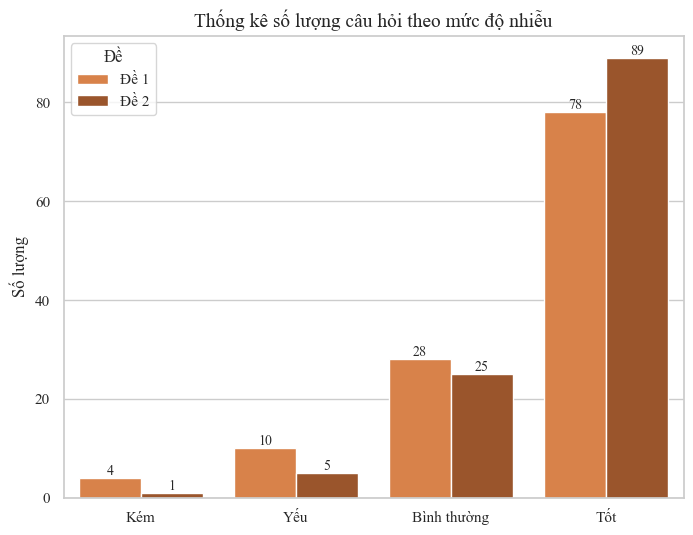

In [36]:
ip.plot_item(nhieu_1, nhieu_2, title='Thống kê số lượng câu hỏi theo mức độ nhiễu', order=order_nhieu, palette='Oranges_d', size=(8,6))

In [37]:
nhieu_1['Phần thi'] = (
    nhieu_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

nhieu_2['Phần thi'] = (
    nhieu_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ nhiễu xét theo từng phần thi của mỗi đợt')

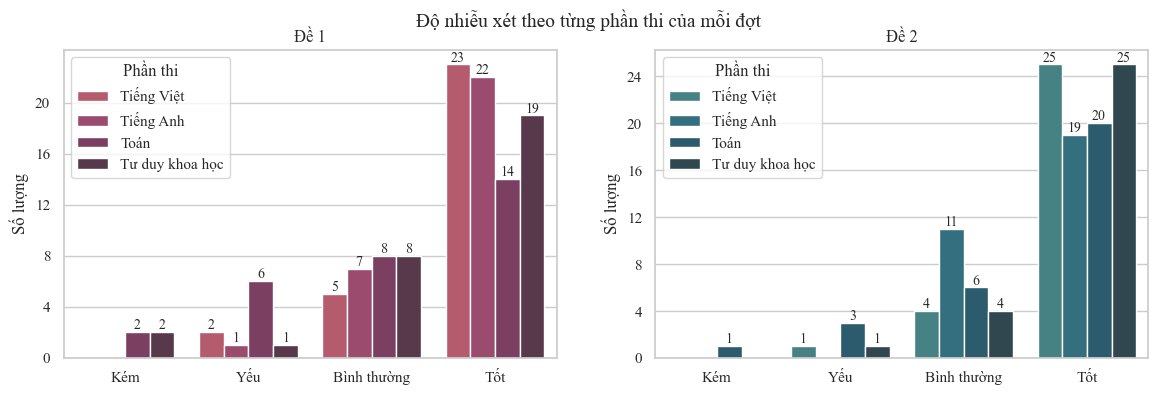

In [82]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
sns.countplot(data=nhieu_1, x='Phân loại', palette='flare_d', ax=axes[0], hue='Phần thi', order=order_nhieu)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=nhieu_2, x='Phân loại', palette='crest_d', ax=axes[1], hue='Phần thi', order=order_nhieu)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 4))
axes[1].set_yticks(range(0, max_y2 + 1, 4))

plt.suptitle('Độ nhiễu xét theo từng phần thi của mỗi đợt', fontsize=14)

In [39]:
diff_1['CTT']

Cau1      0.784188
Cau2      0.882479
Cau3      0.831197
Cau4      0.121795
Cau5      0.314103
            ...   
Cau116    0.263274
Cau117    0.508850
Cau118    0.165929
Cau119    0.579646
Cau120    0.422566
Name: CTT, Length: 120, dtype: float64

In [40]:
item_ctt_1 = pd.concat([
    diff_1.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_1.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_1.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_2 = pd.concat([
    diff_2.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_2.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_2.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

In [41]:
item_ctt_1, item_ctt_2

(             CTT         Độ khó   D-Index   Độ phân biệt         A         B  \
 Cau1    0.784188             Dễ  0.174603       Chưa tốt -0.090698 -0.077724   
 Cau2    0.882479             Dễ  0.182540       Chưa tốt -0.077654 -0.164355   
 Cau3    0.831197             Dễ  0.031746       Chưa tốt  0.023497  0.010622   
 Cau4    0.121795            Khó  0.047619       Chưa tốt  0.098663  0.055808   
 Cau5    0.314103  Tương đối khó  0.166667       Chưa tốt -0.137573  0.120029   
 ...          ...            ...       ...            ...       ...       ...   
 Cau116  0.263274  Tương đối khó  0.590164  Tương đối tốt  0.093254  0.231577   
 Cau117  0.508850    Bình thường  1.032787        Quá tốt -0.146751 -0.147345   
 Cau118  0.165929            Khó  0.557377  Tương đối tốt -0.185613 -0.029800   
 Cau119  0.579646    Bình thường  0.975410        Rất tốt -0.087406  0.508710   
 Cau120  0.422566    Bình thường  0.885246        Rất tốt -0.105607  0.394653   
 
                C         

In [43]:
import textwrap

def wrap_labels(ax, width=10):
    ax.set_xticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_xticklabels()]
    )
    ax.set_yticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_yticklabels()]
    )
    
def heatmap_pair(df, col1, col2, title, cmap, order1=None, order2=None, ax=None):
    if order1 is not None:
        df[col1] = pd.Categorical(df[col1], categories=order1, ordered=True)
    if order2 is not None:
        df[col2] = pd.Categorical(df[col2], categories=order2, ordered=True)

    ct = pd.crosstab(df[col1], df[col2])

    #plt.figure(figsize=(6, 6))
    ax = sns.heatmap(ct, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)

    ax.set_title(title)
    plt.xlabel(col2)
    plt.ylabel(col1)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0) 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    # Tự động xuống dòng
    wrap_labels(ax, width=8)

    plt.tight_layout()

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 1')

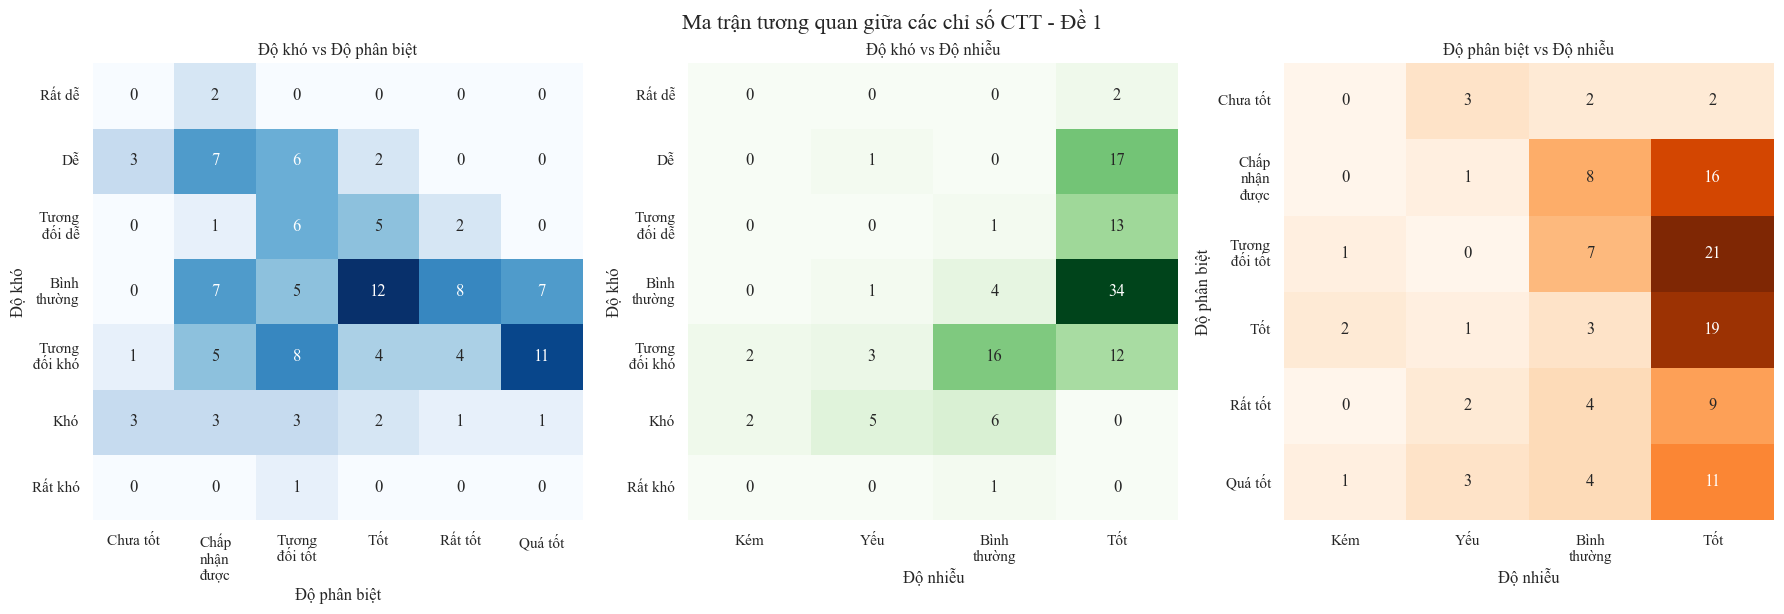

In [52]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_1, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_1, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_1, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 1', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 2')

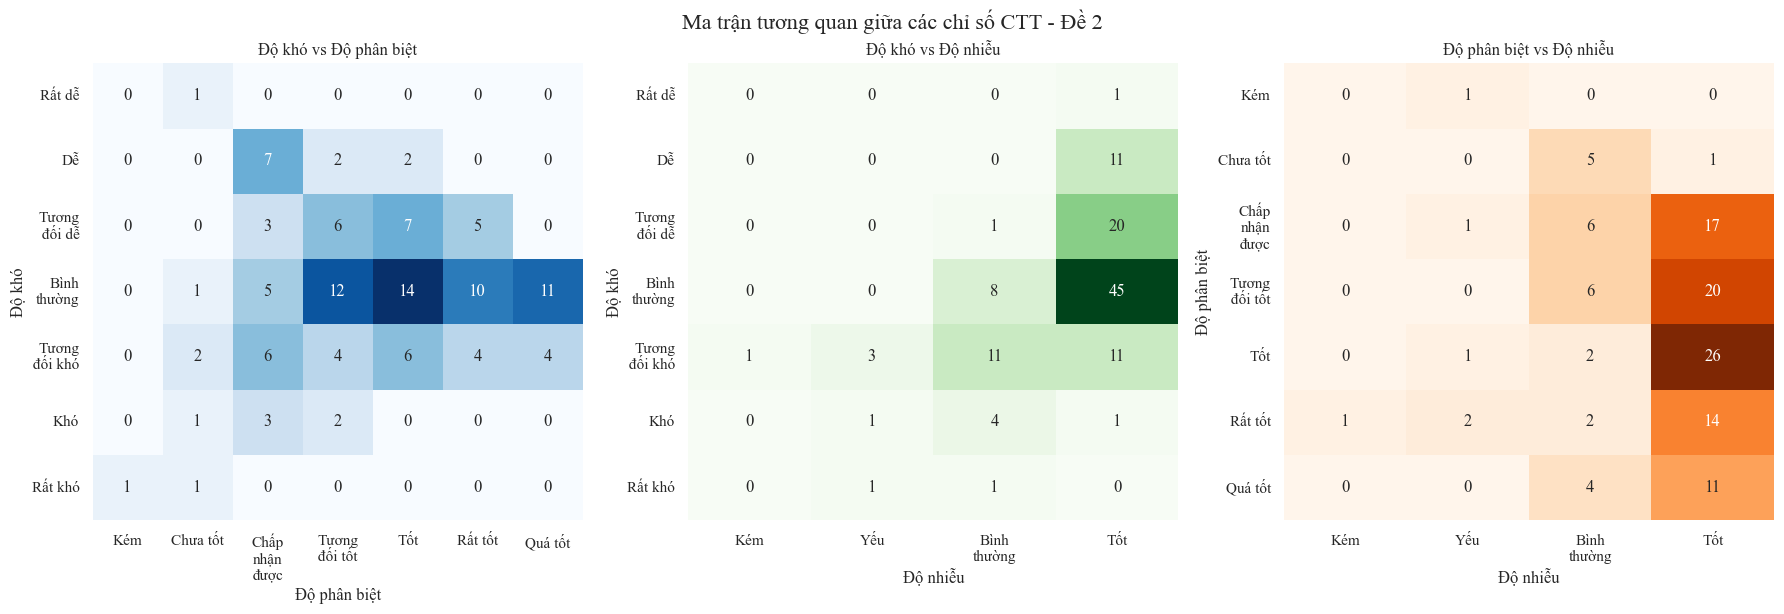

In [53]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_2, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_2, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_2, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 2', fontsize=16, y=1.02)

In [ ]:
a_init_1 = nhieu_1['Ans'].apply(irt.cal_disc)
a_init_2 = nhieu_2['Ans'].apply(irt.cal_disc)
b_init_1 = diff_1['CTT'].apply(irt.cal_diff)
b_init_2 = diff_2['CTT'].apply(irt.cal_diff)

In [92]:
b_init_1.iloc[:30]

Cau1    -1.290241
Cau2    -2.016114
Cau3    -1.594131
Cau4     1.975542
Cau5     0.781009
Cau6    -1.563976
Cau7     1.087249
Cau8     0.197218
Cau9    -0.354081
Cau10   -1.367702
Cau11    0.136966
Cau12   -0.042742
Cau13   -1.534403
Cau14    0.371744
Cau15   -1.789269
Cau16    0.955511
Cau17   -0.389465
Cau18    0.635989
Cau19   -0.275229
Cau20   -0.434038
Cau21   -0.240468
Cau22    0.617161
Cau23    0.533684
Cau24   -0.882137
Cau25   -1.448900
Cau26    0.488097
Cau27   -1.936178
Cau28   -2.578838
Cau29   -1.824549
Cau30    1.110041
Name: CTT, dtype: float64

In [91]:
irt.mmle(U=df_TV1.drop(columns=['SBD','MaDe','Gioi','Raw','Null']).to_numpy(), a_init=a_init_1.iloc[:30], b_init=b_init_1.iloc[:30])

Start MMLE: N=469, J=30, K=81


(array([0.43599244, 0.55897896, 0.42948777, 0.39697174, 0.22877768,
        0.59550837, 0.32053059, 0.29641836, 0.17881654, 0.60046854,
        0.41415416, 0.07377482, 0.55130303, 0.10207154, 0.68008881,
        0.30087043, 0.28332102, 0.29001549, 0.31987157, 0.26405273,
        0.25760043, 0.28830061, 0.20627304, 0.60558186, 0.69284228,
        0.43516615, 0.74340626, 0.7656085 , 0.69727235, 0.29359188]),
 array([-1.82262767, -2.29808191, -2.16882282,  3.0942029 ,  1.89923665,
        -1.77806419,  1.92682854,  0.38837631, -1.17969659, -1.56763472,
         0.17637331, -0.58488433, -1.87222167,  1.71654901, -1.88555166,
         1.81445897, -0.89093761,  1.18144495, -0.66367869, -1.07497756,
        -0.62507974,  1.23193481,  1.31643195, -1.03059021, -1.59705923,
         0.63632266, -2.02285301, -2.64615447, -1.98962821,  2.07956119]))